# Question 1(b): Campbell-Shiller decomposition

The dataset has monthly rows containing annual variables. For each monthly starting row, an annual step therefore advances 12 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Steps 1-3: load the data, create a monthly date, and sort chronologically
df = pd.read_csv("EQ Dataset.csv")
df["date"] = pd.to_datetime(
    {"year": df["YEAR"], "month": df["MONTH"], "day": 1}
)
df = df.sort_values("date").reset_index(drop=True)
df.head()

,YEAR,MONTH,dp,dg,rf,re,date
0,1927,12,-3.143676,0.129874,0.053718,0.298791,1927-12-01
1,1928,1,-3.142009,0.105342,0.042354,0.283000,1928-01-01
2,1928,2,-3.117330,0.101963,0.048949,0.233187,1928-02-01
3,1928,3,-3.203713,0.077818,0.043086,0.307920,1928-03-01
4,1928,4,-3.242533,0.084212,0.042787,0.343425,1928-04-01


In [3]:
# Step 4: check data completeness and verify that row offsets represent months
print("Missing values by column:")
print(df.isna().sum())

month_number = 12 * df["date"].dt.year + df["date"].dt.month
if not month_number.diff().dropna().eq(1).all():
    raise ValueError("The data contain a gap in the monthly time index.")

print(f"\nObservations: {len(df)}")
print(f"Sample: {df['date'].min():%Y-%m} to {df['date'].max():%Y-%m}")

Missing values by column:
YEAR     0
MONTH    0
dp       0
dg       0
rf       0
re       0
date     0
dtype: int64

Observations: 1129
Sample: 1927-12 to 2021-12


In [4]:
# Steps 5-6: calculate the mean log dividend-price ratio and kappa
bar_dp = df["dp"].mean()
kappa = 1 / (1 + np.exp(bar_dp))

print(f"bar_dp = {bar_dp:.9f}")
print(f"kappa  = {kappa:.9f}")

bar_dp = -3.294161665
kappa  = 0.964227978


In [5]:
# Steps 7-11: construct the annual-horizon components and estimate OLS slopes
# For a monthly starting row m, year h is located at row m + 12h.

def ols_slope(y, x):
    """Return the OLS slope from a regression of y on an intercept and x."""
    design = np.column_stack((np.ones(len(x)), x.to_numpy()))
    return np.linalg.lstsq(design, y.to_numpy(), rcond=None)[0][1]


b_re_list = []
b_dg_list = []
b_dpH_list = []
n_obs_list = []

for H in range(1, 21):
    future_return = pd.Series(0.0, index=df.index)
    change_d = pd.Series(0.0, index=df.index)

    for h in range(1, H + 1):
        annual_weight = kappa ** (h - 1)
        future_return += annual_weight * df["re"].shift(-12 * h)
        change_d -= annual_weight * df["dg"].shift(-12 * h)

    dp_H = (kappa ** H) * df["dp"].shift(-12 * H)

    df_H = pd.DataFrame({
        "dp": df["dp"],
        "future_return": future_return,
        "change_d": change_d,
        "dp_H": dp_H,
    }).dropna()

    b_re_list.append(ols_slope(df_H["future_return"], df_H["dp"]))
    b_dg_list.append(ols_slope(df_H["change_d"], df_H["dp"]))
    b_dpH_list.append(ols_slope(df_H["dp_H"], df_H["dp"]))
    n_obs_list.append(len(df_H))

results = pd.DataFrame({
    "H": range(1, 21),
    "b_re": b_re_list,
    "b_dg": b_dg_list,
    "b_dpH": b_dpH_list,
    "n_obs": n_obs_list,
})
results["coefficient_sum"] = results[["b_re", "b_dg", "b_dpH"]].sum(axis=1)
results

,H,b_re,b_dg,b_dpH,n_obs,coefficient_sum
0,1,0.069206,0.139592,0.791859,1117,1.000658
1,2,0.151507,0.210736,0.638361,1105,1.000605
2,3,0.210828,0.231312,0.558096,1093,1.000237
3,4,0.277717,0.236857,0.485328,1081,0.999902
4,5,0.357744,0.233295,0.408258,1069,0.999298
5,6,0.398850,0.234747,0.365184,1057,0.998780
6,7,0.443777,0.229220,0.325377,1045,0.998374
7,8,0.513931,0.238978,0.245336,1033,0.998245
8,9,0.577413,0.225394,0.195612,1021,0.998419
9,10,0.619352,0.208591,0.171027,1009,0.998970


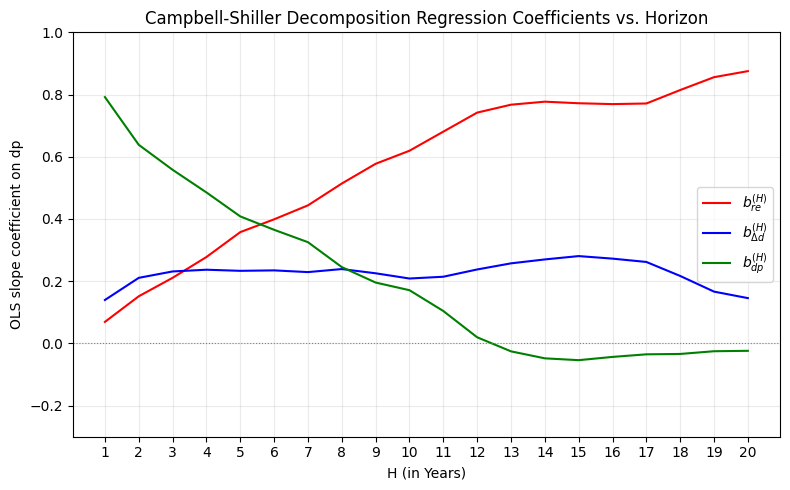

In [6]:
# Step 12: plot the three coefficient series against H
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results["H"], results["b_re"], color="red", label=r"$b_{re}^{(H)}$")
ax.plot(results["H"], results["b_dg"], color="blue", label=r"$b_{\Delta d}^{(H)}$")
ax.plot(results["H"], results["b_dpH"], color="green", label=r"$b_{dp}^{(H)}$")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set(
    xlabel="H (in Years)",
    ylabel="OLS slope coefficient on dp",
    title="Campbell-Shiller Decomposition Regression Coefficients vs. Horizon",
)
ax.set_xticks(range(1, 21))
ax.set_ylim(-0.3, 1.0)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig("figures/q1b_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()